In [12]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt



# Loading data
train = pd.read_csv("train.csv")

train["label"] = (train["target"] > 0).astype(int)

In [13]:
# Features
features = [
    "imbalance_size",
    "imbalance_buy_sell_flag",
    "reference_price",
    "matched_size",
    "far_price",
    "near_price",
    "bid_price",
    "bid_size",
    "ask_price",
    "ask_size",
    "wap"
]

train[features] = train[features].fillna(0)

scaler = StandardScaler()
train[features] = scaler.fit_transform(train[features])

In [14]:
# Dataset
SEQ_LEN = 55

class StockDataset(Dataset):
    def __init__(self, df):
        self.X = []
        self.y = []

        grouped = df.groupby(["stock_id", "date_id"])

        for _, g in grouped:
            g = g.sort_values("seconds_in_bucket")

            if len(g) == SEQ_LEN:
                self.X.append(g[features].values)
                self.y.append(g["label"].iloc[-1])

        self.X = torch.tensor(np.array(self.X), dtype=torch.float32)
        self.y = torch.tensor(np.array(self.y), dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]



In [15]:
# Train / validation split by date
unique_dates = sorted(train["date_id"].unique())
split = int(0.8 * len(unique_dates))

train_dates = unique_dates[:split]
val_dates = unique_dates[split:]

train_df = train[train["date_id"].isin(train_dates)]
val_df = train[train["date_id"].isin(val_dates)]

train_dataset = StockDataset(train_df)
val_dataset = StockDataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [18]:
# GRU Model
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=10):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, x):
        output, hidden = self.gru(x)
        last_hidden = hidden[-1]
        return self.fc(last_hidden)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GRUModel(
    input_size=len(features),
    hidden_size=64,
    num_layers=1
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [19]:
# Training and evaluation
EPOCHS = 10

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        loss = loss_fn(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)

            total_val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = accuracy_score(all_labels, all_preds)

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    print(
        "Epoch:", epoch + 1,
        "| Train Loss:", round(avg_train_loss, 4),
        "| Val Loss:", round(avg_val_loss, 4),
        "| Val Accuracy:", round(val_accuracy, 4)
    )



Epoch: 1 | Train Loss: 0.676 | Val Loss: 0.6671 | Val Accuracy: 0.5946


KeyboardInterrupt: 

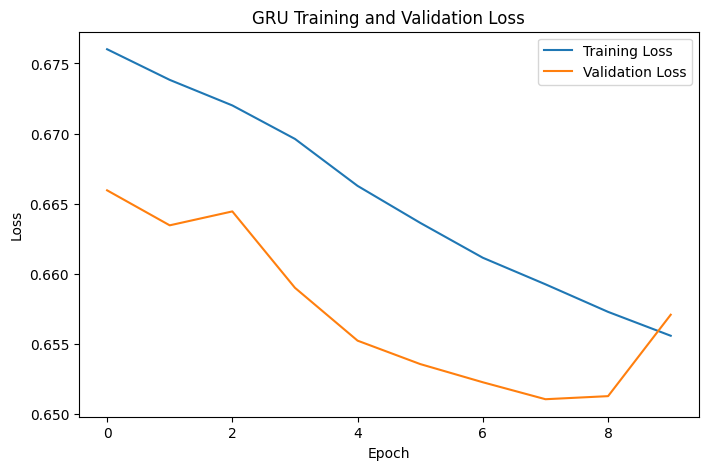

Final Validation Accuracy: 0.6088

              precision    recall  f1-score   support

           0       0.65      0.51      0.57      9848
           1       0.58      0.72      0.64      9552

    accuracy                           0.61     19400
   macro avg       0.62      0.61      0.61     19400
weighted avg       0.62      0.61      0.60     19400

Example Predictions:
Example 1 | Actual: Down | Predicted: Up
Example 2 | Actual: Up | Predicted: Down
Example 3 | Actual: Down | Predicted: Up
Example 4 | Actual: Up | Predicted: Up
Example 5 | Actual: Up | Predicted: Up
Example 6 | Actual: Down | Predicted: Up
Example 7 | Actual: Down | Predicted: Up
Example 8 | Actual: Down | Predicted: Down
Example 9 | Actual: Up | Predicted: Up
Example 10 | Actual: Down | Predicted: Up


In [9]:
# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Training and Validation Loss")
plt.legend()
plt.show()


# Final evaluation
print("Final Validation Accuracy:", round(val_accuracies[-1], 4))
print()
print(classification_report(all_labels, all_preds))


# Example predictions
print("Example Predictions:")

for i in range(min(10, len(all_labels))):
    actual = "Up" if all_labels[i] == 1 else "Down"
    predicted = "Up" if all_preds[i] == 1 else "Down"

    print(
        "Example", i + 1,
        "| Actual:", actual,
        "| Predicted:", predicted
    )

In [20]:
# LSTM Model
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=10):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, x):
        output, hidden = self.lstm(x)
        last_hidden = hidden[-1]
        return self.fc(last_hidden)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTM(
    input_size=len(features),
    hidden_size=64,
    num_layers=1
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [21]:
# Training and evaluation
EPOCHS = 10

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        loss = loss_fn(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)

            total_val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = accuracy_score(all_labels, all_preds)

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    print(
        "Epoch:", epoch + 1,
        "| Train Loss:", round(avg_train_loss, 4),
        "| Val Loss:", round(avg_val_loss, 4),
        "| Val Accuracy:", round(val_accuracy, 4)
    )



ValueError: Expected input batch_size (1) to match target batch_size (64).

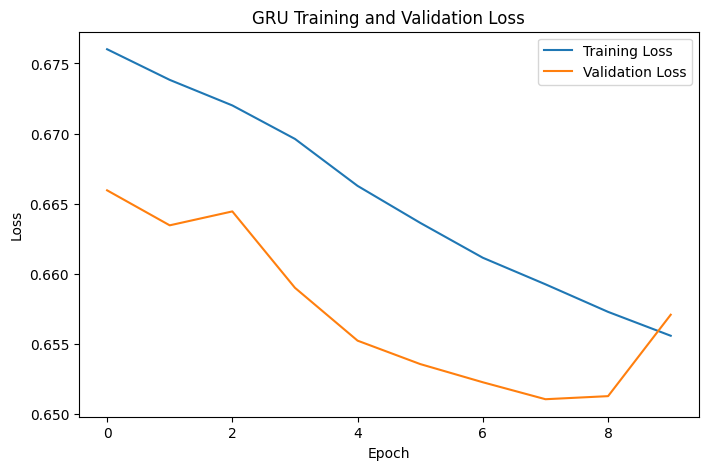

Final Validation Accuracy: 0.6088

              precision    recall  f1-score   support

           0       0.65      0.51      0.57      9848
           1       0.58      0.72      0.64      9552

    accuracy                           0.61     19400
   macro avg       0.62      0.61      0.61     19400
weighted avg       0.62      0.61      0.60     19400

Example Predictions:
Example 1 | Actual: Down | Predicted: Up
Example 2 | Actual: Up | Predicted: Down
Example 3 | Actual: Down | Predicted: Up
Example 4 | Actual: Up | Predicted: Up
Example 5 | Actual: Up | Predicted: Up
Example 6 | Actual: Down | Predicted: Up
Example 7 | Actual: Down | Predicted: Up
Example 8 | Actual: Down | Predicted: Down
Example 9 | Actual: Up | Predicted: Up
Example 10 | Actual: Down | Predicted: Up


In [ ]:
# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.show()


# Final evaluation
print("Final Validation Accuracy:", round(val_accuracies[-1], 4))
print()
print(classification_report(all_labels, all_preds))


# Example predictions
print("Example Predictions:")

for i in range(min(10, len(all_labels))):
    actual = "Up" if all_labels[i] == 1 else "Down"
    predicted = "Up" if all_preds[i] == 1 else "Down"

    print(
        "Example", i + 1,
        "| Actual:", actual,
        "| Predicted:", predicted
    )